# **Image Recognition using a CNN Model**
The task is to build a model that can classify different types of flowers (daisy, dandelion, roses, sunflowers, tulips) and serve it through a Streamlit app.

## Author: Akande Victor
## Date: 31/08/2026

In [ ]:
# import libraries
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from sklearn.metrics import roc_curve, auc, accuracy_score
from sklearn.preprocessing import label_binarize

In [ ]:
# Loading dataset (update DATA_DIR to wherever you extracted flower_photos)
DATA_DIR = '/content/drive/MyDrive/flower_photos'

data_train = tf.keras.preprocessing.image_dataset_from_directory(
    DATA_DIR, validation_split=0.3, subset='training', seed=123,
    image_size=(128, 128), batch_size=500, labels='inferred', label_mode='int')
data_test = tf.keras.preprocessing.image_dataset_from_directory(
    DATA_DIR, validation_split=0.3, subset='validation', seed=123,
    image_size=(128, 128), batch_size=500, labels='inferred', label_mode='int')

Found 3680 files belonging to 5 classes.
Using 2576 files for training.
Found 3680 files belonging to 5 classes.
Using 1104 files for validation.


# **Data Exploration**
At this stage we look at the classes in the dataset and view sample images from them, as shown below.

In [ ]:
# familarise with the class name and there index
class_names = data_train.class_names
print(class_names)

# Get unique class labels from the dataset
class_labels =data_train.class_names

# Create a dictionary mapping class labels to indices
class_indices = {label: index for index, label in enumerate(class_labels)}

# Print the class indices
print("Class Indices:", class_indices)

['daisy', 'dandelion', 'roses', 'sunflowers', 'tulips']
Class Indices: {'daisy': 0, 'dandelion': 1, 'roses': 2, 'sunflowers': 3, 'tulips': 4}


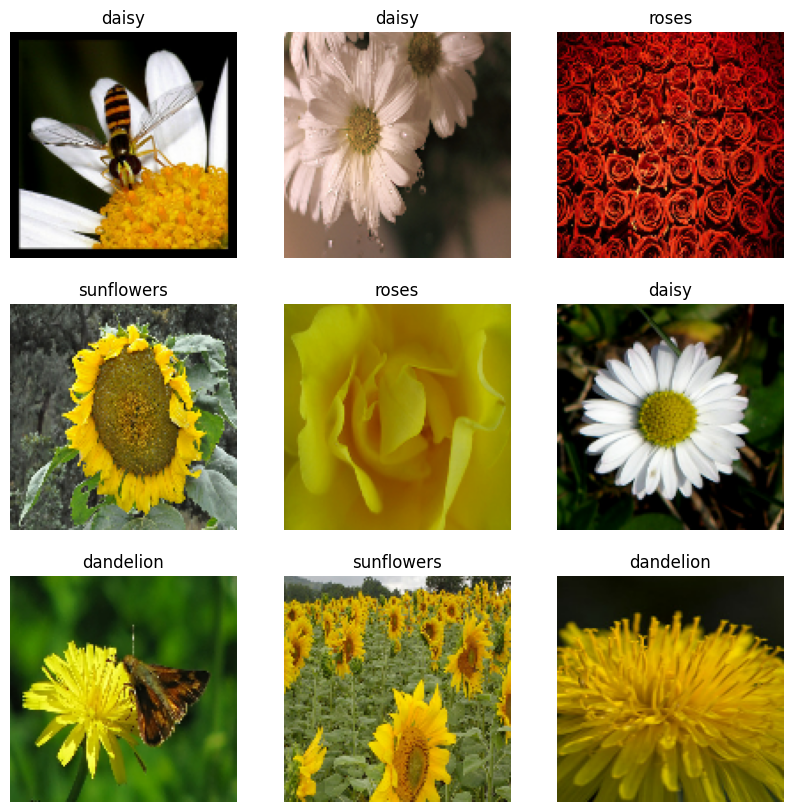

In [ ]:
# display the first 10 images

plt.figure(figsize=(10, 10))
for images, labels in data_train.take(1):
  for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(images[i].numpy().astype("uint8"))
    plt.title(class_names[labels[i]])
    plt.axis("off")

# **Data Pre-processing**
To help the model perform better during training and tell the flower types apart, data augmentation is applied. Augmentation pre-processes the images by flipping, rotating and zooming them, which exposes the model to more variation while training.

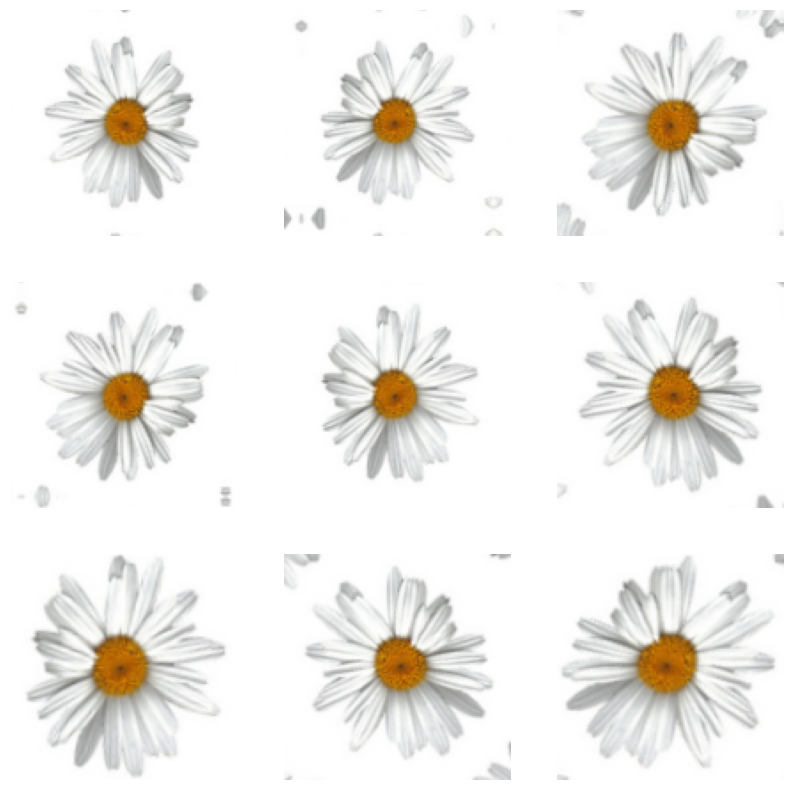

In [ ]:
data_augmentation = tf.keras.Sequential([tf.keras.layers.RandomFlip("horizontal"),
                                          tf.keras.layers.RandomRotation(0.2),
                                          tf.keras.layers.RandomZoom(0.2)
                                          ])

plt.figure(figsize=(10, 10))
for images, labels in data_train.take(1):
  for i in range(9):
    augmented_images = data_augmentation(images)
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(augmented_images[0].numpy().astype("uint8"))
    plt.axis("off")

# **Model Building**
The model uses a sequence of Conv2D layers with increasing filter counts, allowing the network to learn hierarchical features at different levels of abstraction. The 'relu' activation is applied after each convolutional layer, adding non-linearity and increasing the model's ability to capture complex patterns. MaxPooling2D layers follow the convolutional layers, reducing spatial dimensions and computational cost while retaining key features. The Flatten layer converts the 2D feature maps into vectors, and the dense layers at the end build high-level representations for prediction.

The 'softmax' activation in the output layer suits multi-class classification, as it produces a probability distribution across the classes. The model uses the 'adam' optimizer with 'sparse_categorical_crossentropy' loss.

**Note:** the model is trained on raw pixel values (0-255) with no Rescaling layer, so any inference code (e.g. the Streamlit app) must feed raw 0-255 pixels too.

In [ ]:
# Define the CNN model
model = models.Sequential([
    tf.keras.Input(shape=(128, 128, 3)), # Explicitly define input shape
    data_augmentation,
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(256, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(512, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(5, activation='softmax')  # 5 classes
])

model.summary()

# Compile the model
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Train the model
history = model.fit(data_train, epochs=60, validation_data=data_test)

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 12, 12, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 4, 4, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 2, 2, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,831,493 (6.99 MB)

 Trainable params: 1,831,493 (6.99 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/60
6/6 ━━━━━━━━━━━━━━━━━━━━ 462s 80s/step - accuracy: 0.2205 - loss: 35.3978 - val_accuracy: 0.1658 - val_loss: 2.5398
Epoch 2/60
6/6 ━━━━━━━━━━━━━━━━━━━━ 13s 2s/step - accuracy: 0.2415 - loss: 1.7670 - val_accuracy: 0.2600 - val_loss: 1.5474
Epoch 3/60
6/6 ━━━━━━━━━━━━━━━━━━━━ 13s 2s/step - accuracy: 0.3082 - loss: 1.4954 - val_accuracy: 0.3143 - val_loss: 1.4572
Epoch 4/60
6/6 ━━━━━━━━━━━━━━━━━━━━ 21s 2s/step - accuracy: 0.3909 - loss: 1.3807 - val_accuracy: 0.3850 - val_loss: 1.4689
Epoch 5/60
6/6 ━━━━━━━━━━━━━━━━━━━━ 11s 2s/step - accuracy: 0.4305 - loss: 1.2952 - val_accuracy: 0.4194 - val_loss: 1.2623
Epoch 6/60
6/6 ━━━━━━━━━━━━━━━━━━━━ 12s 2s/step - accuracy: 0.4499 - loss: 1.2049 - val_accuracy: 0.4556 - val_loss: 1.2039
Epoch 7/60
6/6 ━━━━━━━━━━━━━━━━━━━━ 12s 2s/step - accuracy: 0.5144 - loss: 1.1524 - val_accuracy: 0.5163 - val_loss: 1.1745
Epoch 8/60
6/6 ━━━━━━━━━━━━━━━━━━━━ 21s 2s/step - accuracy: 0.5229 - loss: 1.1048 - val_accuracy: 0.5018 - val_loss: 1.2518
Epoch

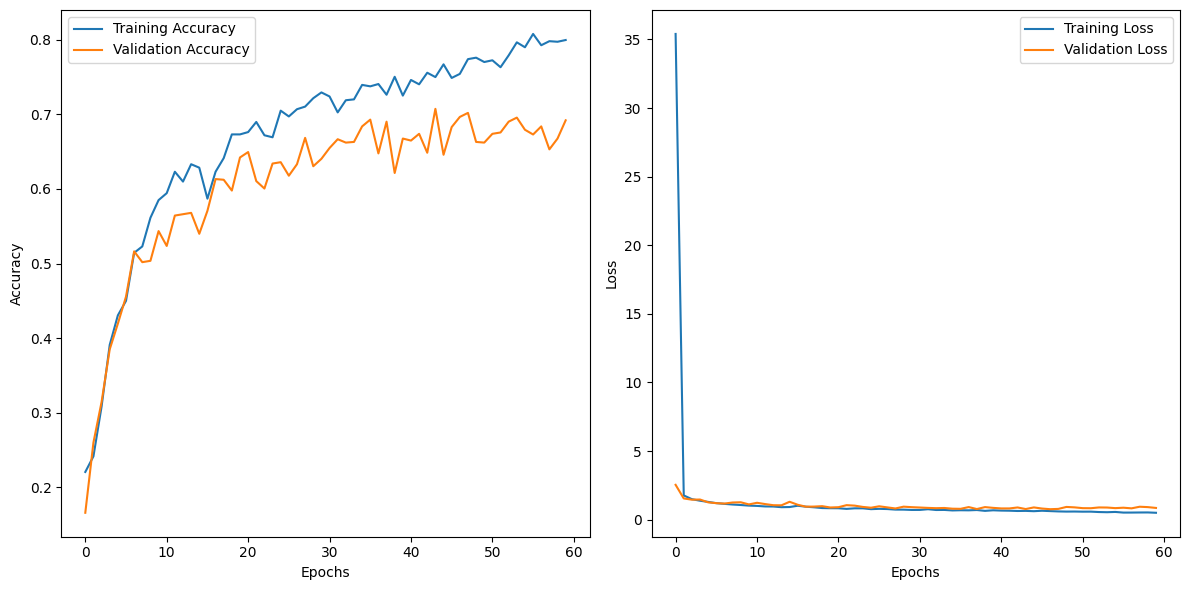

In [ ]:
# Plot training and validation Accuracy
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Plot training and validation loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()


# **Model Evaluation**
Predictions and true labels are collected in one pass so they stay aligned. Accuracy is measured on the held-out 30% validation split.

In [ ]:
# Collect predictions and true labels in a SINGLE pass over the dataset.
# image_dataset_from_directory reshuffles on every iteration, so calling
# model.predict(data_test) and iterating data_test separately gives
# mismatched predictions/labels (and a meaningless ~chance accuracy).
y_true, y_pred = [], []
for x, y in data_test:
    y_true.append(y.numpy())
    y_pred.append(model.predict(x, verbose=0))
y_true = np.concatenate(y_true)
y_pred = np.concatenate(y_pred)

# convert the labels to one-hot form
y_true_onehot = label_binarize(y_true, classes=[0, 1, 2, 3, 4])

# ROC curve and ROC area for each class
fpr, tpr, roc_auc = {}, {}, {}
for i in range(5):
    fpr[i], tpr[i], _ = roc_curve(y_true_onehot[:, i], y_pred[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot ROC curves
plt.figure(figsize=(8, 8))
for i in range(5):
    plt.plot(fpr[i], tpr[i], label=f'{class_names[i]} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', linewidth=2)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend()
plt.show()

# Overall accuracy
y_pred_classes = y_pred.argmax(axis=1)
accuracy = accuracy_score(y_true, y_pred_classes)
print(f'Overall Accuracy: {accuracy:.2%}')

In [ ]:
# saving of the model
model.save('flower_model1.h5')

In [ ]:
import sys

# Install Streamlit
!{sys.executable} -m pip install streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 72.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 96.8 MB/s eta 0:00:00


Now, let's create the Streamlit application code. This code will be saved to a file named `app.py`. It will load your trained model and provide an interface to upload an image and get a prediction.

In [ ]:
%%writefile app.py

import streamlit as st
import tensorflow as tf
from tensorflow import keras
import numpy as np
from PIL import Image

# Load the trained model
@st.cache_resource
def load_model():
    return keras.models.load_model('flower_model1.h5')

model = load_model()

# Class names (same order as training: alphabetical folder names)
class_names = ['daisy', 'dandelion', 'roses', 'sunflowers', 'tulips']

st.set_page_config(page_title="Flower Classification App", page_icon="🌸")

st.title("🌸 Flower Classification App 🌸")
st.write("Upload an image of a flower to get its classification!")

uploaded_file = st.file_uploader("Choose an image...", type=["jpg", "jpeg", "png"])

if uploaded_file is not None:
    # Display the uploaded image
    image = Image.open(uploaded_file).convert('RGB')
    st.image(image, caption='Uploaded Image', use_container_width=True)
    st.write("Classifying...")

    # Preprocess: the model was trained on raw 0-255 pixels (no Rescaling layer),
    # so do NOT divide by 255 here.
    img_array = np.array(image.resize((128, 128)), dtype="float32")
    img_array = np.expand_dims(img_array, axis=0)  # add batch dimension

    # The model already ends in softmax, so predictions are probabilities
    probs = model.predict(img_array)[0]

    st.write(f"This image most likely belongs to **{class_names[np.argmax(probs)]}** "
             f"with a **{100 * np.max(probs):.2f}%** confidence.")

    st.subheader("All Probabilities:")
    for name, p in zip(class_names, probs):
        st.write(f"- {name}: {100 * p:.2f}%")
else:
    st.write("Please upload an image file to classify.")

Writing app.py


After running the above cell, you'll have an `app.py` file in your Colab environment. To run the Streamlit app, you would typically execute the following command in your terminal:

```bash
!streamlit run app.py & npx localtunnel --port 8501
```

**Note:** In Google Colab, you might need to use `npx localtunnel` to expose the Streamlit port (default 8501) to the internet, as Colab environments are not directly accessible. The command above will print a public URL that you can click to access your app.

In [ ]:
!streamlit run app.py & npx localtunnel --port 8501

In [ ]:
import subprocess

print('Starting localtunnel...')
process = subprocess.Popen(['npx', 'localtunnel', '--port', '8501'], stdout=subprocess.PIPE, stderr=subprocess.PIPE, text=True)

# Read output until 'your url is:' is found
for line in iter(process.stdout.readline, ''):
    print(line, end='')
    if 'your url is:' in line:
        # The URL is in this line or the next few, let localtunnel continue
        break

# Keep the process running to maintain the tunnel
# Note: This will block the cell indefinitely until the kernel is interrupted.
# You can interrupt the kernel (Ctrl+M I or Runtime -> Interrupt execution) if you want to stop the tunnel.
# In a real scenario, you might want a more sophisticated way to manage this in Colab,
# but for direct user interaction, this is often sufficient.

# You can also try to extract the URL directly if you want to display it more prominently
# (this is an example, actual parsing might vary based on localtunnel output)
# import re
# match = re.search(r'your url is:\s*(https?://\S+)', line)
# if match:
#     print(f"Access your Streamlit app here: {match.group(1)}")


The cell above is designed to keep the `localtunnel` running. Once you see the 'your url is:' line, copy that URL and paste it into your browser.

**Important:** This cell will run indefinitely to keep the tunnel open. If you want to stop the Streamlit app and the tunnel, you will need to interrupt the execution of this cell (e.g., by clicking the stop button next to the cell, or `Runtime -> Interrupt execution` from the Colab menu).